In [ ]:
# 1. Setup: Install libraries (Fixed typo: added -q for quiet install)
!pip -q install sentence-transformers chromadb scikit-learn pandas matplotlib seaborn

import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.utils import embedding_functions

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the so

In [ ]:
# 2. Load the specific model requested in your assignment
model_name = "sentence-transformers/all-MiniLM-L6-v2"
model = SentenceTransformer(model_name)

# Helper function from your teacher's template
def embed(texts, normalize=True):
    if isinstance(texts, str):
        texts = [texts]
    # We normalize so that L2 distance in ChromaDB behaves like Cosine Similarity
    return model.encode(texts, convert_to_numpy=True, normalize_embeddings=normalize)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

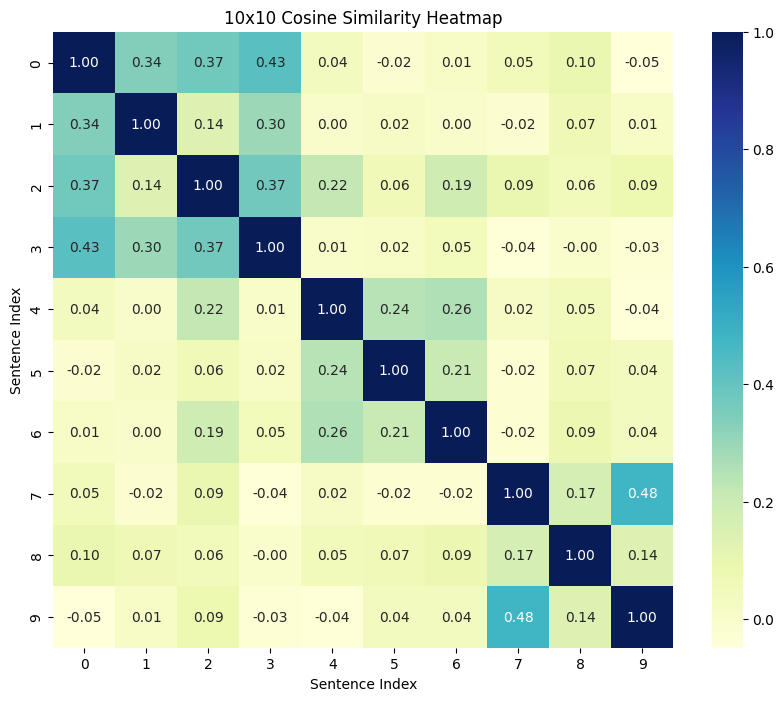

In [ ]:
# 3. Task Requirement: 10 sentences across 3 topics
sentences = [
    # Topic: Cricket
    "The batsman hit a massive six over the long-on boundary.",
    "The test match ended in a thrilling draw after five days of play.",
    "Fast bowlers often use the seam to get movement off the pitch.",
    "The umpire raised his finger to signal an LBW dismissal.",
    # Topic: Cooking
    "Slow-cooking the stew allows the flavors to meld together perfectly.",
    "Always preheat the oven before baking a sourdough loaf.",
    "Whisk the egg whites until they form stiff, glossy peaks.",
    # Topic: Cybersecurity
    "Multi-factor authentication adds a critical layer of security to accounts.",
    "A zero-day exploit targets vulnerabilities that are not yet patched.",
    "Phishing emails often use social engineering to steal user credentials."
]

# 4. Task Requirement: 10x10 Cosine Similarity Matrix Heatmap
emb_s = embed(sentences)
sim_matrix = cosine_similarity(emb_s, emb_s)

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("10x10 Cosine Similarity Heatmap")
plt.xlabel("Sentence Index")
plt.ylabel("Sentence Index")
plt.show()

In [ ]:
# 5. Task Requirement: Top 2 similar sentences for the specific query
query = "The bowler took three wickets in one over"
query_vec = embed(query)
query_sims = cosine_similarity(query_vec, emb_s)[0]

# Get indices of top 2 (sorting descending)
top_indices = np.argsort(query_sims)[-2:][::-1]

print(f"Query: {query}\n")
print("Top 2 Most Similar Sentences:")
for idx in top_indices:
    print(f"- {sentences[idx]} (Score: {query_sims[idx]:.4f})")

Query: The bowler took three wickets in one over

Top 2 Most Similar Sentences:
- The batsman hit a massive six over the long-on boundary. (Score: 0.5319)
- Fast bowlers often use the seam to get movement off the pitch. (Score: 0.4573)


In [ ]:
# 6. Teacher's Extra Credit: ChromaDB Implementation
# This part uses the Vector DB logic from your teacher's template
class SbertEmbeddingFunction(embedding_functions.EmbeddingFunction):
    def __call__(self, texts):
        return embed(texts).tolist()

client = chromadb.Client()
# Using a fresh name to avoid errors on re-run
collection = client.get_or_create_collection(
    name="assignment_demo",
    embedding_function=SbertEmbeddingFunction()
)

# Add our 10 sentences to the Vector Database
collection.add(
    ids=[f"id-{i}" for i in range(len(sentences))],
    documents=sentences
)

print(f"\nVector DB status: {collection.count()} documents inserted.")


Vector DB status: 10 documents inserted.


/tmp/ipykernel_298/2183080341.py:11: DeprecationWarning: The class SbertEmbeddingFunction does not implement __init__. This will be required in a future version.
  embedding_function=SbertEmbeddingFunction()
